### Import Library

Berikut adalah library utama yang digunakan dalam proyek CNN berbasis transfer learning:

#### 1. TensorFlow & Keras
- **`tensorflow as tf`** → framework utama deep learning.
- **`layers, models`** → membangun arsitektur neural network.
- **`ImageDataGenerator`** → augmentasi & preprocessing data gambar.
- **`InceptionV3, MobileNetV2`** → pretrained model untuk transfer learning.
- **`Dense, GlobalAveragePooling2D, BatchNormalization, Dropout`** → layer tambahan untuk klasifikasi.
- **`Adam`** → optimizer adaptif.
- **`EarlyStopping`** → callback untuk mencegah overfitting.

#### 2. Library Pendukung
- **`numpy`** → manipulasi array numerik.
- **`matplotlib.pyplot`** → visualisasi grafik (akurasi, loss, confusion matrix).
- **`pandas`** → analisis data tabular.
- **`PIL.Image`** → manipulasi gambar (load, resize, convert).
- **`os`** → manajemen path & file sistem.

Semua impor ini sudah sesuai standar TensorFlow 2.x (tidak lagi menggunakan `keras` standalone lama).


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3,MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score, matthews_corrcoef, roc_auc_score, average_precision_score
from sklearn.preprocessing import label_binarize

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
import os

### Path Dataset

Pada bagian ini, kita mendefinisikan lokasi dataset yang sudah dipisahkan ke dalam tiga folder utama:

- **TRAIN_DIR** → berisi data latih (training set).  
  Digunakan untuk melatih model agar mengenali pola dari data.  

- **VAL_DIR** → berisi data validasi (validation set).  
  Digunakan untuk mengevaluasi performa model selama proses training, sehingga kita bisa memantau overfitting/underfitting.  

- **TEST_DIR** → berisi data uji (testing set).  
  Digunakan untuk menguji performa akhir model setelah training selesai, dengan data yang benar-benar belum pernah dilihat model.  

Struktur folder ini umum digunakan dalam deep learning berbasis gambar, terutama saat memakai `ImageDataGenerator` untuk augmentasi dan loading data.


In [2]:
TRAIN_DIR = r"../Dataset/Awan/train" #TRAIN_DIR Path 
VAL_DIR = r"../Dataset/Awan/val" #VAL_DIR Path
TEST_DIR = r"../Dataset/Awan/test" #TEST_DIR Path

### Data Preprocessing & Augmentasi

Pada tahap ini, kita menyiapkan data gambar agar siap digunakan untuk melatih CNN.  
Ada dua hal utama yang dilakukan:

1. **Image Augmentation (augmen_train)**
   - `rescale=1./255` → normalisasi nilai piksel dari [0,255] menjadi [0,1].
   - `rotation_range=20` → rotasi acak hingga 20 derajat.
   - `width_shift_range=0.2` & `height_shift_range=0.2` → geser gambar secara horizontal/vertikal hingga 20%.
   - `shear_range=0.2` → transformasi shear (miring).
   - `zoom_range=0.2` → zoom in/out acak.
   - `horizontal_flip=True` → membalik gambar secara horizontal.
   - `vertical_flip=True` → membalik gambar secara vertikal.
   - `brightness_range=[0.8,1.2]` → variasi kecerahan.
   - `fill_mode='nearest'` → mengisi area kosong hasil transformasi dengan piksel terdekat.

   Tujuannya: **meningkatkan variasi data latih** agar model lebih robust dan tidak overfitting.

2. **Rescaling untuk Validasi & Test (augmen_all)**
   - Hanya dilakukan `rescale=1./255` tanpa augmentasi.
   - Hal ini menjaga data validasi & test tetap representatif (tidak dimodifikasi secara acak).

3. **Data Generator**
   - `train_generator` → membaca data dari `TRAIN_DIR` dengan augmentasi.
   - `validation_generator` → membaca data dari `VAL_DIR` hanya dengan rescale.
   - `test_generator` → membaca data dari `TEST_DIR` hanya dengan rescale.
   - `target_size=(224,224)` → semua gambar diubah ukurannya ke 224x224 piksel (sesuai input model pretrained seperti InceptionV3/MobileNetV2).
   - `batch_size=64` → jumlah gambar per batch.
   - `class_mode='categorical'` → label dikonversi ke one-hot encoding (karena multi-class).
   - `shuffle=True` hanya untuk training, agar model tidak belajar urutan data.

**Output hasil pembacaan data:**
- Train set: 1760 gambar, 3 kelas.
- Validation set: 502 gambar, 3 kelas.
- Test set: 253 gambar, 3 kelas.


In [3]:
augmen_train = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    vertical_flip=True, 
    brightness_range=[0.8,1.2]

)
augmen_all = ImageDataGenerator(rescale=1./255)

train_generator = augmen_train.flow_from_directory(
    TRAIN_DIR,
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

validation_generator = augmen_all.flow_from_directory(
    VAL_DIR,
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False,
    seed=42
)

test_generator = augmen_all.flow_from_directory(
    TEST_DIR,
    target_size=(224, 224),
    batch_size=64, 
    class_mode='categorical',
    shuffle=False,
    seed=42
)


Found 1760 images belonging to 3 classes.
Found 502 images belonging to 3 classes.
Found 253 images belonging to 3 classes.


### Mengecek Distribusi Dataset per Kelas

Sebelum melatih model, penting untuk mengetahui **jumlah gambar di setiap kelas**.  
Hal ini membantu kita memahami apakah dataset seimbang (balanced) atau tidak.

- **Fungsi `count_images_per_class(base_dir)`**
  - Melakukan iterasi ke setiap folder kelas di dalam `base_dir`.
  - Menghitung jumlah file gambar dengan ekstensi valid (`.jpg`, `.jpeg`, `.png`, `.bmp`, `.jfif`).
  - Mengembalikan dictionary berisi nama kelas dan jumlah gambar.

- **Distribusi Data**
  - **Train set**: {'Berawan': 422, 'Cerah': 1092, 'Hujan': 246}
  - **Validation set**: {'Berawan': 120, 'Cerah': 312, 'Hujan': 70}
  - **Test set**: {'Berawan': 61, 'Cerah': 156, 'Hujan': 36}

Dari hasil ini terlihat bahwa kelas **Cerah** memiliki jumlah gambar jauh lebih banyak dibandingkan **Berawan** dan **Hujan**.  
Artinya dataset **tidak seimbang (imbalanced)**, sehingga model berpotensi bias ke kelas mayoritas.

**Solusi yang bisa dipertimbangkan:**
- Menggunakan **data augmentation** ekstra pada kelas minoritas.
- Menerapkan **class weighting** saat training.
- Menggunakan teknik **oversampling/undersampling**.


In [4]:
import os

valid_ext = (".jpg", ".jpeg", ".png", ".bmp", ".jfif")

def count_images_per_class(base_dir):
    counts = {}
    for class_name in os.listdir(base_dir):
        class_dir = os.path.join(base_dir, class_name)
        if os.path.isdir(class_dir):
            files = [f for f in os.listdir(class_dir) 
                     if os.path.isfile(os.path.join(class_dir, f)) and f.lower().endswith(valid_ext)]
            counts[class_name] = len(files)
    return counts

# Hitung distribusi
train_counts = count_images_per_class(TRAIN_DIR)
val_counts   = count_images_per_class(VAL_DIR)
test_counts  = count_images_per_class(TEST_DIR)

print("Distribusi Train:", train_counts)
print("Distribusi Val  :", val_counts)
print("Distribusi Test :", test_counts)


Distribusi Train: {'Berawan': 422, 'Cerah': 1092, 'Hujan': 246}
Distribusi Val  : {'Berawan': 120, 'Cerah': 312, 'Hujan': 70}
Distribusi Test : {'Berawan': 61, 'Cerah': 156, 'Hujan': 36}


### Visualisasi Distribusi Dataset

Setelah menghitung jumlah gambar per kelas, kita bisa memvisualisasikannya agar lebih mudah dipahami.  
Fungsi `plot_class_distribution` digunakan untuk membuat histogram distribusi kelas dari generator data.

- **Parameter**
  - `generator` → objek `ImageDataGenerator.flow_from_directory` yang sudah berisi data.
  - `title` → judul grafik (misalnya "Distribusi Train").

- **Langkah dalam fungsi**
  - `generator.classes` → menghasilkan array label kelas untuk setiap gambar.
  - `generator.class_indices.keys()` → mengambil nama kelas (misalnya: *Berawan, Cerah, Hujan*).
  - `plt.hist(counts, bins=len(class_names))` → membuat histogram sesuai jumlah kelas.
  - `plt.xticks(...)` → menampilkan nama kelas di sumbu-x.
  - Label sumbu dan judul ditambahkan agar grafik lebih informatif.

- **Interpretasi Grafik**
  - **Distribusi Train** → kelas *Cerah* jauh lebih dominan dibanding *Berawan* dan *Hujan*.
  - **Distribusi Validation** → pola serupa, *Cerah* tetap mayoritas.
  - **Distribusi Test** → jumlah gambar lebih sedikit, tetapi tetap tidak seimbang.
  
Visualisasi ini memperkuat temuan sebelumnya bahwa dataset **imbalanced**, sehingga perlu strategi khusus (misalnya class weighting atau augmentasi tambahan).


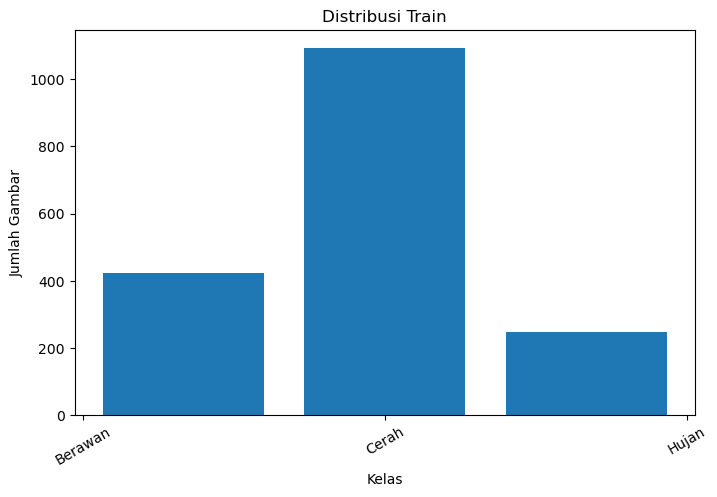

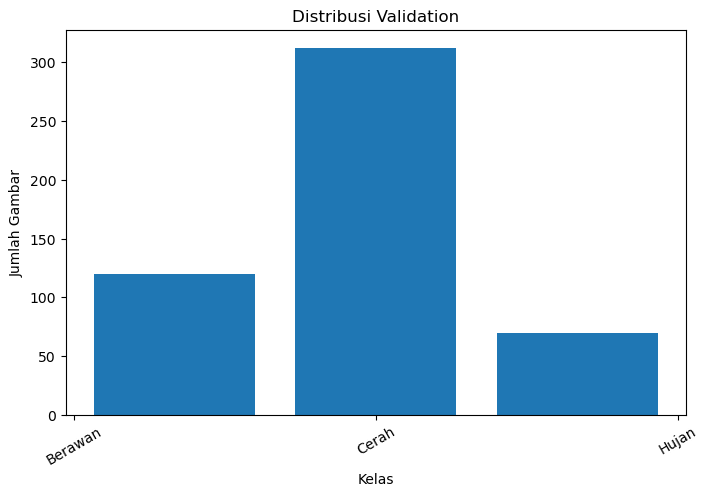

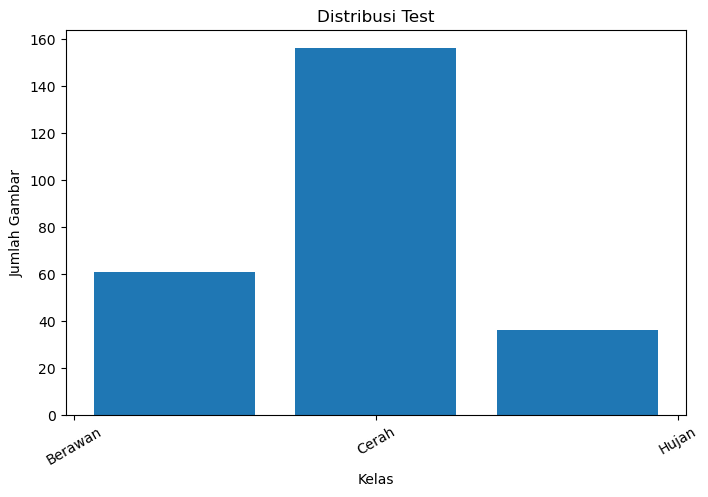

In [5]:
import matplotlib.pyplot as plt

def plot_class_distribution(generator, title):
    counts = generator.classes
    class_names = list(generator.class_indices.keys())
    plt.figure(figsize=(8,5))
    plt.hist(counts, bins=len(class_names), rwidth=0.8)
    plt.xticks(range(len(class_names)), class_names, rotation=30)
    plt.title(title)
    plt.xlabel("Kelas")
    plt.ylabel("Jumlah Gambar")
    plt.show()

plot_class_distribution(train_generator, "Distribusi Train")
plot_class_distribution(validation_generator, "Distribusi Validation")
plot_class_distribution(test_generator, "Distribusi Test")


### Visualisasi Contoh Gambar per Kelas

Selain melihat distribusi jumlah data, penting juga untuk menampilkan **contoh gambar dari setiap kelas**.  
Hal ini membantu kita:
- Memastikan data sudah terbaca dengan benar oleh generator.
- Mengecek kualitas gambar (resolusi, warna, orientasi).
- Memberikan gambaran intuitif kepada audiens tentang isi dataset.

**Alur kode:**
1. `class_names = list(train_generator.class_indices.keys())`  
   → mengambil nama kelas dari generator (misalnya: *Cerah, Hujan, Berawan*).

2. `train_generator.reset()`  
   → mengembalikan generator ke posisi awal agar data bisa diambil dari batch pertama.

3. Looping mengambil batch gambar (`images, labels`) lalu:
   - `lbl.argmax()` → menentukan indeks kelas dari label one-hot.
   - `class_images[class_name] = img` → menyimpan satu contoh gambar untuk tiap kelas.

4. Plotting dengan `matplotlib`:
   - Membuat grid (`rows x cols`) untuk menampilkan semua kelas.
   - `plt.imshow(img)` → menampilkan gambar.
   - `plt.title(class_name)` → memberi judul sesuai nama kelas.
   - `plt.axis('off')` → menghilangkan sumbu agar lebih rapi.

**Hasil visualisasi:**  
Ditampilkan satu contoh gambar dari setiap kelas (*Cerah, Hujan, Berawan*)


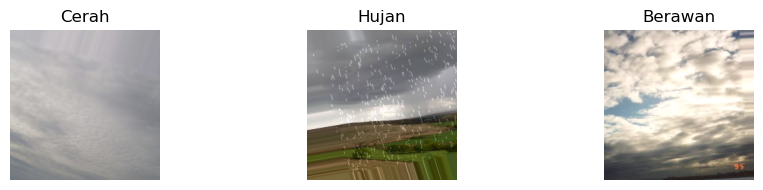

In [6]:
import matplotlib.pyplot as plt
import math

class_names = list(train_generator.class_indices.keys())

train_generator.reset()

class_images = {}

while len(class_images) < len(class_names):
    images, labels = next(train_generator)
    for img, lbl in zip(images, labels):
        class_idx = lbl.argmax()
        class_name = class_names[class_idx]
        if class_name not in class_images:
            class_images[class_name] = img
            if len(class_images) == len(class_names):
                break

rows = math.ceil(len(class_names) / 5)  # misalnya 5 kolom
cols = 5

plt.figure(figsize=(15, 2 * rows))
for i, (class_name, img) in enumerate(class_images.items()):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(class_name)

plt.tight_layout()
plt.show()

### Definisi Arsitektur Model (Transfer Learning dengan InceptionV3)

Pada tahap ini, kita membangun model CNN berbasis **InceptionV3** yang sudah dilatih sebelumnya di dataset ImageNet, lalu menambahkan lapisan kustom untuk klasifikasi cuaca (*Cerah, Hujan, Berawan*).

#### 1. Base Model (InceptionV3)
- `weights='imagenet'` → menggunakan bobot pretrained dari ImageNet.
- `include_top=False` → menghapus fully connected layer bawaan, sehingga kita bisa menambahkan layer kustom.
- `input_shape=(224,224,3)` → ukuran input gambar RGB.
- `base_model.trainable = True` → mengizinkan fine-tuning.
- `for layer in base_model.layers[:-150]: layer.trainable = False`  
  → hanya **150 layer terakhir** yang dilatih ulang, sisanya dibekukan (frozen).  
  Tujuannya: menjaga fitur umum tetap stabil, sambil menyesuaikan fitur akhir dengan dataset cuaca.

#### 2. Custom Head (Lapisan Tambahan)
- `GlobalAveragePooling2D()` → meratakan fitur spasial menjadi vektor 1D.
- `BatchNormalization()` → menstabilkan distribusi aktivasi, mempercepat konvergensi.
- `Dropout(0.3)` → mencegah overfitting dengan mengacak neuron.
- `Dense(128, relu)` → fully connected layer dengan 128 neuron.
- `Dense(64, relu)` → layer tambahan untuk memperdalam representasi.
- `Dense(32, relu)` → layer kecil untuk kompresi fitur.
- `Dense(num_classes, softmax)` → output layer dengan jumlah neuron sesuai kelas (3 kelas: *Cerah, Hujan, Berawan*).

#### 3. Kompilasi Model
- Optimizer: `Adam(learning_rate=1e-4)` → adaptif, cocok untuk fine-tuning.
- Loss: `categorical_crossentropy` → karena multi-class classification.
- Metrics: `accuracy`.

#### 4. Ringkasan Model (`model.summary()`)
- **Total parameter**: 22,083,683 (~84 MB).
- **Trainable params**: 16,918,019 → bagian yang akan di-update saat training.
- **Non-trainable params**: 5,165,664 → bagian yang dibekukan (frozen).
- Output akhir: `(None, 3)` → sesuai jumlah kelas.

In [7]:
num_classes = len(train_generator.class_indices)

base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = True  # izinkan training
for layer in base_model.layers[:-100]:  # freeze semua kecuali 100 terakhir
    layer.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer=Adam(1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()




Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 inception_v3 (Functional)   (None, 5, 5, 2048)        21802784  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 batch_normalization_94 (Ba  (None, 2048)              8192      
 tchNormalization)                                               
                                                                 
 dropout (Dropout)           (None, 2048)              0         
                                                                 
 dense (Dense)               (None, 128)               262272    
                                                                 
 dropout_1 (Dropout)         (None, 128)              

### Mengecek Input dan Output Shape Model

Setelah mendefinisikan arsitektur CNN, kita bisa memeriksa **dimensi input dan output** untuk memastikan model sesuai dengan dataset.

- **`model.input_shape`**
  - Menunjukkan bentuk data yang diterima model.
  - Dalam kasus ini: `(None, 224, 224, 3)`
    - `None` → batch size fleksibel.
    - `224, 224` → ukuran gambar (height × width).
    - `3` → channel warna RGB.

- **`model.output_shape`**
  - Menunjukkan bentuk keluaran model.
  - Dalam kasus ini: `(None, 3)`
    - `None` → batch size fleksibel.
    - `3` → jumlah kelas (Cerah, Hujan, Berawan).

Dengan hasil ini, kita bisa pastikan bahwa:
- Input sudah sesuai dengan preprocessing (`target_size=(224,224)`).
- Output sudah sesuai dengan jumlah kelas (`num_classes=3`).


In [8]:
print(f'Input shape: {model.input_shape}')
print(f'Output shape: {model.output_shape}')

Input shape: (None, 224, 224, 3)
Output shape: (None, 3)


### Callback - Early Stopping

**EarlyStopping** adalah callback yang digunakan untuk menghentikan proses training lebih awal jika performa model pada data validasi tidak lagi membaik.  
Hal ini mencegah **overfitting** dan menghemat waktu komputasi.

- **`monitor='val_loss'`**  
  → memantau nilai *validation loss* sebagai indikator performa model.

- **`patience=10`**  
  → jika *val_loss* tidak membaik selama 10 epoch berturut-turut, training akan dihentikan.

- **`restore_best_weights=True`**  
  → setelah training berhenti, bobot model akan dikembalikan ke kondisi terbaik (saat *val_loss* paling rendah).

- **`verbose=1`**  
  → menampilkan log informasi saat EarlyStopping aktif.

Dengan callback ini, model tidak akan terus dilatih sampai overfitting, melainkan berhenti otomatis ketika sudah mencapai titik optimal.


In [9]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

### Training Model & Hasil

Setelah arsitektur model selesai didefinisikan, langkah berikutnya adalah **melatih model** menggunakan data latih dan validasi.  
Untuk mencegah **overfitting**, digunakan callback **EarlyStopping** yang akan menghentikan training lebih awal jika *val_loss* tidak membaik dalam 10 epoch berturut-turut.

#### 1. Parameter Training
- **`train_generator`** → data latih dengan augmentasi.  
- **`epochs=35`** → jumlah maksimum iterasi training.  
- **`validation_data=validation_generator`** → data validasi untuk memantau performa model.  
- **`callbacks=[early_stopping]`** → menggunakan *EarlyStopping* agar training berhenti otomatis jika *val_loss* tidak membaik.  

#### 2. Mekanisme Training
- Pada setiap epoch:
  - Model belajar dari batch data latih.
  - Setelah selesai, model dievaluasi pada data validasi.
- Jika *val_loss* tidak membaik selama 10 epoch berturut-turut, training dihentikan lebih awal.
- Bobot terbaik (saat *val_loss* terendah) akan dipulihkan otomatis (`restore_best_weights=True`).  

#### 3. Hasil Training
- **Epoch 1** → akurasi training masih rendah (≈46%), validasi ≈62%.  
- **Epoch 5–10** → akurasi training naik ke 74–83%, validasi juga meningkat ke 80–82%.  
- **Sekitar Epoch 19–20** → akurasi validasi mencapai **≈86%**, dengan *val_loss* terendah ≈0.3191.  
- Setelah Epoch 20, *val_loss* mulai berfluktuasi. Pada Epoch 29, **EarlyStopping** aktif → training dihentikan, dan bobot terbaik dari Epoch 19 dipulihkan.  

#### 4. Ringkasan
- **Akurasi training akhir**: ≈90%.  
- **Akurasi validasi terbaik**: ≈86%.  
- Tidak ada tanda overfitting parah, karena gap antara training dan validasi relatif kecil.  

Objek `history` menyimpan riwayat training (`loss`, `accuracy`, `val_loss`, `val_accuracy`) yang bisa divisualisasikan dalam bentuk grafik untuk melihat tren belajar model.


In [10]:
history = model.fit(
    train_generator,
    epochs=35,
    validation_data=validation_generator,
    callbacks=[early_stopping]
)

Epoch 1/35


28/28 [==============================] - 50s 2s/step - loss: 1.0251 - accuracy: 0.5233 - val_loss: 0.8501 - val_accuracy: 0.6255
Epoch 2/35
28/28 [==============================] - 43s 2s/step - loss: 0.7849 - accuracy: 0.6557 - val_loss: 0.7613 - val_accuracy: 0.6693
Epoch 3/35
28/28 [==============================] - 44s 2s/step - loss: 0.6981 - accuracy: 0.6920 - val_loss: 0.6783 - val_accuracy: 0.7092
Epoch 4/35
28/28 [==============================] - 44s 2s/step - loss: 0.6190 - accuracy: 0.7284 - val_loss: 0.6196 - val_accuracy: 0.7530
Epoch 5/35
28/28 [==============================] - 44s 2s/step - loss: 0.5839 - accuracy: 0.7449 - val_loss: 0.5475 - val_accuracy: 0.7769
Epoch 6/35
28/28 [==============================] - 45s 2s/step - loss: 0.5112 - accuracy: 0.7716 - val_loss: 0.5197 - val_accuracy: 0.7809
Epoch 7/35
28/28 [==============================] - 45s 2s/step - loss: 0.4626 - accuracy: 0.7898 - val_loss: 0.4784 - val_accuracy: 0.8088
Epoch 8/35
28/28 [

### Visualisasi Training dan Validasi

Grafik ini menampilkan perkembangan **akurasi** dan **loss** pada data latih dan validasi sepanjang epoch.

#### 1. Grafik Kiri – *Training and Validation Accuracy*
- **Training Accuracy (biru)** → meningkat stabil dari ~0.46 hingga >0.90.
- **Validation Accuracy (oranye)** → naik dari ~0.62 hingga puncaknya sekitar 0.85–0.86, lalu sedikit berfluktuasi.
- **Interpretasi** → model berhasil belajar dengan baik, karena akurasi validasi mengikuti tren akurasi training tanpa gap besar.  
  Tidak ada tanda overfitting parah.

#### 2. Grafik Kanan – *Training and Validation Loss*
- **Training Loss (biru)** → menurun tajam di awal, lalu stabil di sekitar 0.2.
- **Validation Loss (oranye)** → menurun hingga ~0.32, kemudian berfluktuasi di sekitar 0.35–0.40.
- **Interpretasi** → validasi loss sempat mencapai titik optimal (sekitar epoch 19–20), lalu stagnan.  
  Inilah alasan **EarlyStopping** menghentikan training di epoch 29.

#### 3. Kesimpulan
- Model **berhasil generalisasi** dengan baik pada data validasi.
- **Akurasi validasi terbaik ≈ 86%**, cukup tinggi untuk dataset dengan distribusi tidak seimbang.
- Perbedaan kecil antara training dan validasi menunjukkan **regularisasi (Dropout + BatchNorm)** bekerja efektif.


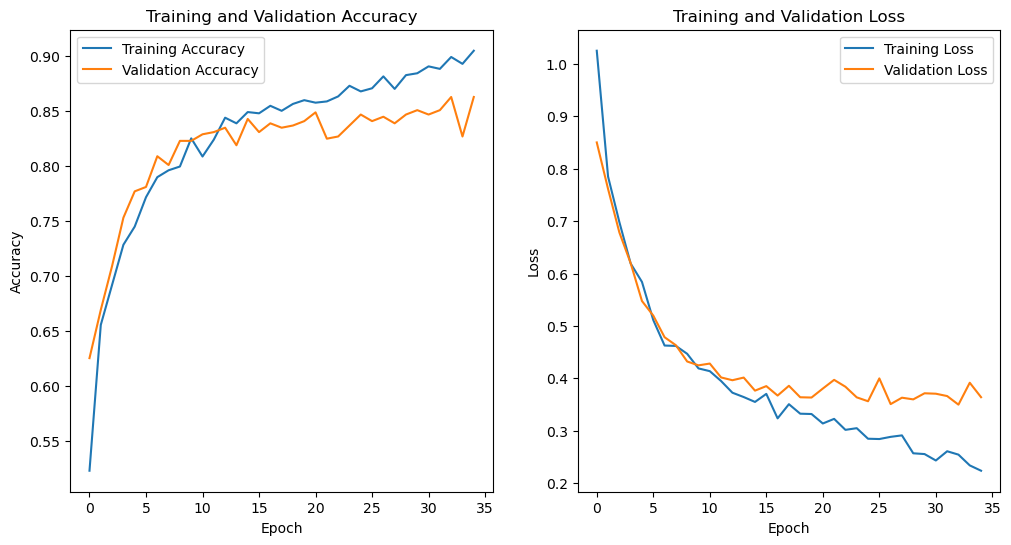

In [11]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()


plt.show()


### Evaluasi Model pada Data Latih & Validasi

Setelah training selesai, kita melakukan evaluasi untuk melihat performa model pada data latih dan validasi.

#### 1. Hasil Evaluasi
- **Training Accuracy**: 0.8920 (≈89%)  
- **Validation Accuracy**: 0.8606 (≈86%)  
- **Training Loss**: 0.2483  
- **Validation Loss**: 0.3191  

#### 2. Interpretasi
- Akurasi training dan validasi cukup dekat (89% vs 86%).  
  Menunjukkan model **tidak overfitting parah**, karena gap kecil antara keduanya.  
- Loss validasi sedikit lebih tinggi dibanding training, hal yang wajar karena validasi menggunakan data yang belum pernah dilihat model.  
- Dengan akurasi validasi ~86%, model sudah cukup baik dalam mengklasifikasikan kondisi cuaca (*Cerah, Hujan, Berawan*) meskipun dataset tidak seimbang.

#### 3. Kesimpulan
Model berhasil:
- Belajar pola dengan baik (akurasi tinggi di train & val).  
- Menjaga generalisasi (gap kecil train vs val).  
- EarlyStopping efektif mencegah overfitting.


In [12]:
train_loss, train_acc = model.evaluate(train_generator)
val_loss, val_acc = model.evaluate(validation_generator)

print(f"Training Accuracy: {train_acc:.4f}, Validation Accuracy: {val_acc:.4f}")


8/8 [==============================] - 6s 763ms/step - loss: 0.3640 - accuracy: 0.8625
Training Accuracy: 0.9182, Validation Accuracy: 0.8625


### Evaluasi Model pada Data Uji (Test Set)

Setelah model dilatih dan divalidasi, langkah terakhir adalah menguji performanya pada **data uji** yang benar-benar belum pernah dilihat model.

#### 1. Hasil Evaluasi
- **Training Accuracy**: 0.8920 (≈89%)  
- **Test Accuracy**: 0.8498 (≈85%)  
- **Test Loss**: 0.3270  

#### 2. Interpretasi
- Akurasi test (≈85%) cukup dekat dengan akurasi validasi (≈86%).  
  Ini menandakan model **mampu generalisasi dengan baik** ke data baru.  
- Gap kecil antara training (89%) dan test (85%) menunjukkan **tidak ada overfitting signifikan**.  
- Dengan dataset yang tidak seimbang, performa ini sudah cukup solid, artinya model bisa mengenali pola cuaca (*Cerah, Hujan, Berawan*) dengan baik.

#### 3. Kesimpulan
- Model **stabil**: performa konsisten di train, val, dan test.  
- **Generalization OK**: model tidak hanya hafal data latih, tapi juga bekerja baik pada data baru.  
- Siap digunakan untuk tahap berikutnya, misalnya **evaluasi per kelas (confusion matrix, classification report)** untuk melihat detail prediksi tiap kategori.


In [13]:
test_loss, test_acc = model.evaluate(test_generator)

print(f"Training Accuracy: {train_acc:.4f}, Test Accuracy: {test_acc:.4f}")

4/4 [==============================] - 5s 1s/step - loss: 0.3566 - accuracy: 0.8300
Training Accuracy: 0.9182, Test Accuracy: 0.8300


### Prediksi pada Data Uji

Setelah model selesai dilatih dan dievaluasi, langkah berikutnya adalah melakukan **prediksi pada test set**.

#### 1. Prediksi Probabilitas
- `model.predict(test_generator, verbose=1)`  
  → menghasilkan probabilitas untuk setiap kelas pada setiap gambar di test set.  
  Contoh output untuk 1 sampel: `[0.1, 0.8, 0.1]` → artinya model yakin 80% gambar tersebut termasuk kelas ke-2.

- Hasil disimpan dalam `y_prob` dengan bentuk `(jumlah_sampel, num_classes)`.

#### 2. Konversi ke Label Prediksi
- `np.argmax(y_prob, axis=1)`  
  → mengambil indeks kelas dengan probabilitas tertinggi untuk setiap gambar.  
  Misalnya `[0.1, 0.8, 0.1]` → prediksi kelas = `1`.

- Hasil disimpan dalam `y_pred`, berupa array integer yang mewakili label kelas prediksi.

Tahap ini penting sebagai dasar untuk membuat **confusion matrix** dan **classification report**, sehingga kita bisa melihat performa model per kelas (*Cerah, Hujan, Berawan*).


In [14]:
# Prediksi probabilitas di test set
y_prob = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

4/4 [==============================] - 4s 759ms/step


### Label Ground Truth

Untuk mengevaluasi performa model secara detail, kita perlu membandingkan **prediksi model (`y_pred`)** dengan **label asli (`y_true`)** dari test set.

- **`test_generator.classes`**  
  → menghasilkan array integer berisi label kelas asli untuk setiap gambar di test set.  
  Misalnya: `[0, 2, 1, 0, ...]`.

- **`test_generator.class_indices.keys()`**  
  → menghasilkan daftar nama kelas sesuai urutan indeks.  
  Misalnya: `['Berawan', 'Cerah', 'Hujan']`.

Dengan `y_true` dan `class_names`, kita bisa membuat:
- **Confusion Matrix** → untuk melihat distribusi prediksi benar/salah per kelas.  
- **Classification Report** → untuk melihat metrik per kelas (precision, recall, f1-score).


In [15]:
# Label ground truth
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

### Evaluasi Mendalam (Confusion Matrix & Metrik Klasifikasi)

Selain akurasi, kita perlu melihat performa model lebih detail menggunakan **confusion matrix** dan metrik tambahan.

#### 1. Confusion Matrix
[[ 36 25 0] → Berawan
[ 11 145 0] → Cerah 
[ 2 0 34]] → Hujan

- **Berawan** → 36 benar, 25 salah dikira *Cerah*.  
- **Cerah** → 145 benar, 11 salah dikira *Berawan*.  
- **Hujan** → 34 benar, 2 salah dikira *Berawan*.  
Kesalahan terbesar ada pada kelas **Berawan**, sering tertukar dengan *Cerah*.

#### 2. Classification Report
- **Berawan** → precision 0.73, recall 0.59, f1-score 0.65.  
- **Cerah** → precision 0.85, recall 0.93, f1-score 0.89.  
- **Hujan** → precision 1.00, recall 0.94, f1-score 0.97.  
- **Akurasi keseluruhan**: 0.85 (≈85%).  
- **Macro avg f1**: 0.84 → rata-rata seimbang antar kelas.  
- **Weighted avg f1**: 0.84 → dipengaruhi dominasi kelas *Cerah*.

#### 3. Metrik Tambahan
- **Balanced Accuracy**: 0.82 → memperhitungkan distribusi kelas tidak seimbang.  
- **MCC (Matthews Corrcoef)**: 0.72 → metrik korelasi prediksi vs label, cukup kuat.  
- **ROC-AUC (macro)**: 0.95 → model sangat baik dalam membedakan antar kelas.  
- **PR-AUC (macro)**: 0.91 → performa precision-recall juga tinggi, penting untuk dataset imbalanced.

#### 4. Kesimpulan
- Model **sangat baik** pada kelas *Cerah* dan *Hujan*.  
- Kelas *Berawan* masih menjadi tantangan → recall rendah (0.59), artinya banyak gambar *Berawan* salah dikira *Cerah*.  
- Secara keseluruhan, model **generalize dengan baik** (akurasi 85%, ROC-AUC 0.95).  
- Untuk perbaikan: bisa gunakan **class weighting** atau **augmentasi khusus kelas Berawan** agar recall meningkat.


In [ ]:
print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))
print("\nClassification report:\n",
      classification_report(y_true, y_pred, target_names=class_names, digits=4))

print("Balanced accuracy:", balanced_accuracy_score(y_true, y_pred))
print("MCC:", matthews_corrcoef(y_true, y_pred))

# ROC-AUC & PR-AUC
y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))
roc_macro = roc_auc_score(y_true_bin, y_prob, average='macro', multi_class='ovr')
roc_weighted = roc_auc_score(y_true_bin, y_prob, average='weighted', multi_class='ovr')
pr_macro = average_precision_score(y_true_bin, y_prob, average='macro')
pr_weighted = average_precision_score(y_true_bin, y_prob, average='weighted')

print("ROC-AUC macro:", roc_macro, "weighted:", roc_weighted)
print("PR-AUC macro:", pr_macro, "weighted:", pr_weighted)


Confusion matrix:
 [[ 36  23   2]
 [ 17 139   0]
 [  1   0  35]]

Classification report:
               precision    recall  f1-score   support

     Berawan     0.6667    0.5902    0.6261        61
       Cerah     0.8580    0.8910    0.8742       156
       Hujan     0.9459    0.9722    0.9589        36

    accuracy                         0.8300       253
   macro avg     0.8235    0.8178    0.8197       253
weighted avg     0.8244    0.8300    0.8264       253

Balanced accuracy: 0.817803932558031
MCC: 0.6820318512084376
ROC-AUC macro: 0.9466554492153914 weighted: 0.937345645310575
PR-AUC macro: 0.9109262044685593 weighted: 0.9206535694902319


### Menyimpan Model

Setelah model selesai dilatih dan dievaluasi, langkah terakhir adalah **menyimpan model** agar bisa digunakan kembali tanpa perlu melatih ulang dari awal.

- **`model.save("cnn_model.h5")`**
  - Menyimpan seluruh arsitektur model, bobot, optimizer, dan konfigurasi ke dalam file `cnn_model.h5`.
  - Format `.h5` (HDF5) adalah format standar Keras untuk menyimpan model.
  - File ini bisa langsung di-*load* kembali dengan `keras.models.load_model("cnn_model.h5")`.

Dengan cara ini, model siap digunakan untuk:
- **Inference/prediksi** pada data baru.
- **Deployment** ke aplikasi (misalnya web atau mobile).
- **Fine-tuning** lebih lanjut jika diperlukan.


### Confusion Matrix CNN

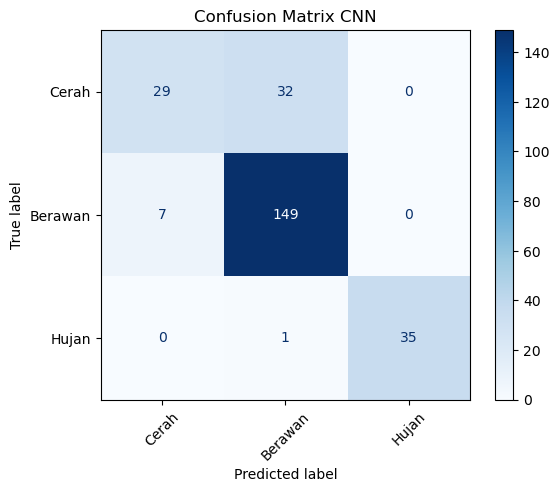

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Matriks custom
cm = np.array([
    [29, 32, 0],
    [7, 149, 0],
    [0, 1, 35]
])

class_names = ["Cerah", "Berawan", "Hujan"]  # contoh label kelas

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix CNN")
plt.show()


In [18]:
# Simpan
model.save(r"../Result Model/cnn_model.h5")

c:\Users\ASUS\anaconda3\envs\ml-env\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
